## SEABORN

In [1]:
#!uv add seaborn

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [3]:
%matplotlib inline

In [4]:
df = pd.read_csv('gapminder.csv')

### JOINPLOT

El jointplot es increíble porque te permite ver tres cosas a la vez:
- La relación entre dos variables (dispersión).
- La distribución de la variable X (histograma superior).
- La distribución de la variable Y (histograma lateral).

"¿Existe una relación clara entre la riqueza de un país y su esperanza de vida? Utiliza un jointplot para analizar todos los países en el año 2007. Observa no solo los puntos, sino también los histogramas en los bordes: ¿Hacia dónde se concentran la mayoría de los países en términos de salud y dinero?"

In [5]:
# Filtramos los datos del 2007
data_2007 = df[df['year'] == 2007]

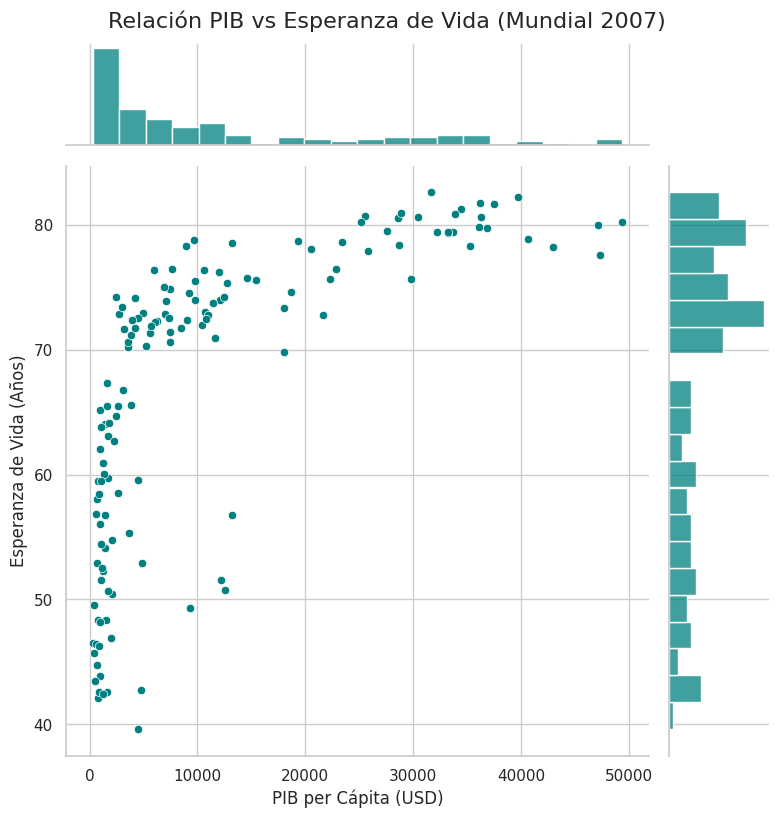

In [6]:
# Configuramos el estilo de Seaborn
sns.set_theme(style="whitegrid")

# Creamos el jointplot
g = sns.jointplot(
    data=data_2007,
    x="gdpPercap", 
    y="lifeExp",
    kind="scatter", # Puede ser "reg", "hex", "kde"
    color="teal",
    height=8,
    marginal_kws=dict(bins=20, fill=True) # Configuración de los histogramas de los bordes
)

# Añadir títulos (en jointplot se hace un poco diferente)
g.fig.suptitle("Relación PIB vs Esperanza de Vida (Mundial 2007)", y=1.02, fontsize=16)
g.set_axis_labels("PIB per Cápita (USD)", "Esperanza de Vida (Años)")

plt.show()

"Observa el histograma superior (PIB). ¿Ves cómo casi todas las barras están al principio? Eso nos dice que la mayoría de los países son pobres, mientras que solo unos pocos tienen riquezas extremas."

### DISPLOT
- Es mucho más "inteligente" porque, además de las barras, puede dibujar una línea suave (KDE) que nos muestra la tendencia de los datos.

"Si pudieras ver a todos los países del mundo en una sola gráfica, ¿crees que la mayoría vive muchos años o pocos? Vamos a usar un displot para ver la 'forma' de la salud mundial en 2007. ¿Hay una sola montaña o ves dos picos distintos?"

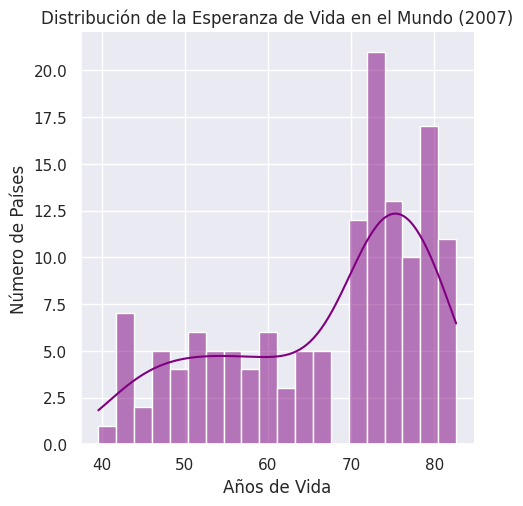

In [11]:
# Configuramos el estilo
sns.set_theme(style="darkgrid")

# Creamos el gráfico de distribución
sns.displot(data=data_2007, 
            x="lifeExp", 
            kde=True,       # Agrega la línea de densidad suave
            color="purple", 
            bins=20)

# Títulos
plt.title("Distribución de la Esperanza de Vida en el Mundo (2007)")
plt.xlabel("Años de Vida")
plt.ylabel("Número de Países")

plt.show()

La curva KDE: La línea que aparece encima de las barras ayuda a los alumnos a ver la "silueta" de los datos sin distraerse con cada barra individual.

Visualización de Desigualdad: En este gráfico, los alumnos notarán que hay un pico muy alto cerca de los 75-80 años, pero también un "bulto" menor cerca de los 50. Eso representa la brecha entre países desarrollados y en desarrollo.

### Boxplot

A diferencia de una barra que solo te da el promedio, la "caja" te muestra dónde está la mayoría de la gente, y los "bigotes" te muestran los extremos (el país que vive más y el que vive menos).

"Vamos a comparar la esperanza de vida por continente en el año 2007. ¿En qué continente la 'caja' es más corta (todos viven años similares) y en cuál es más larga (hay mucha diferencia entre vecinos)? ¿Ves algún punto solo por ahí abajo? Esos son los casos atípicos o 'outliers'."

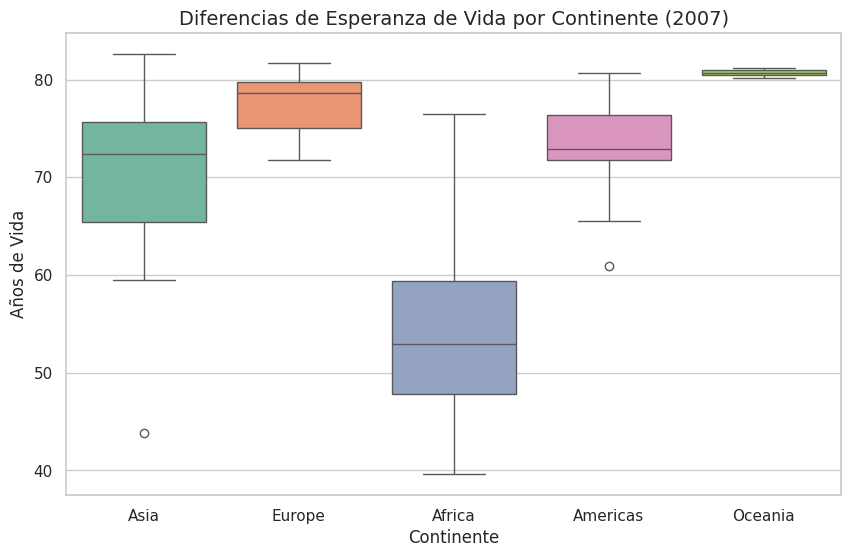

In [12]:
# Configuramos un estilo elegante
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

# Creamos el boxplot
# x es la categoría (Continente) e y es el valor numérico (Esperanza de Vida)
sns.boxplot(data=data_2007, x="continent", y="lifeExp", palette="Set2", hue="continent", legend=False)

# Títulos
plt.title("Diferencias de Esperanza de Vida por Continente (2007)", fontsize=14)
plt.xlabel("Continente")
plt.ylabel("Años de Vida")

plt.show()

- La línea del medio: Es la mediana (el valor justo en el centro de todos los países).
- La caja: Representa al 50% de los países. Si la caja es pequeña, significa que esos países viven de forma muy parecida.
- Los bigotes: Llegan hasta los países con los valores más altos y bajos.
- Los puntos (Outliers): Son países que están "fuera de lo normal" para su continente. Por ejemplo, un país africano que vive mucho más que sus vecinos resaltará como un punto.

"Mira a Europa comparado con África. ¿Por qué la caja de Europa está tan arriba y es tan pequeña, mientras que la de África es enorme y está abajo? ¿Qué nos dice eso sobre la equidad en cada continente?"

### HEADMAP

El heatmap (o mapa de calor) es la forma más rápida de ver las "amistades" entre variables. Nos dice, numéricamente, si cuando una cosa sube (como el dinero), la otra también sube (como la salud).

"¿Qué tan conectados están el dinero, la salud y la cantidad de gente en un país? Vamos a crear un mapa de calor para ver la correlación. Un número cercano a 1 significa que son 'mejores amigos' y crecen juntos. Un número cercano a 0 significa que no tienen nada que ver. ¿Qué relación es más fuerte?"

In [13]:
# 1. Seleccionamos solo las columnas con números
# 2. Calculamos la correlación (.corr())
# "La correlación (corr) es un número que nos dice qué tan bien bailan dos variables juntas. Si una se mueve, ¿la otra la sigue?"
# +1 (Correlación Positiva Perfecta): Son mejores amigas. Si una sube, la otra sube exactamente en la misma proporción. (Ejemplo: A más horas de estudio, mejor calificación).
# 0 (Sin Correlación): No se conocen. Lo que haga una no le afecta a la otra. (Ejemplo: Tu estatura y tu gusto por el helado de chocolate).
# -1 (Correlación Negativa Perfecta): Son enemigas. Si una sube, la otra baja. (Ejemplo: A más velocidad en el auto, menos tiempo para llegar al destino).
matriz_correlacion = df[['lifeExp', 'pop', 'gdpPercap']].corr()

print(matriz_correlacion)

            lifeExp       pop  gdpPercap
lifeExp    1.000000  0.064955   0.583706
pop        0.064955  1.000000  -0.025600
gdpPercap  0.583706 -0.025600   1.000000


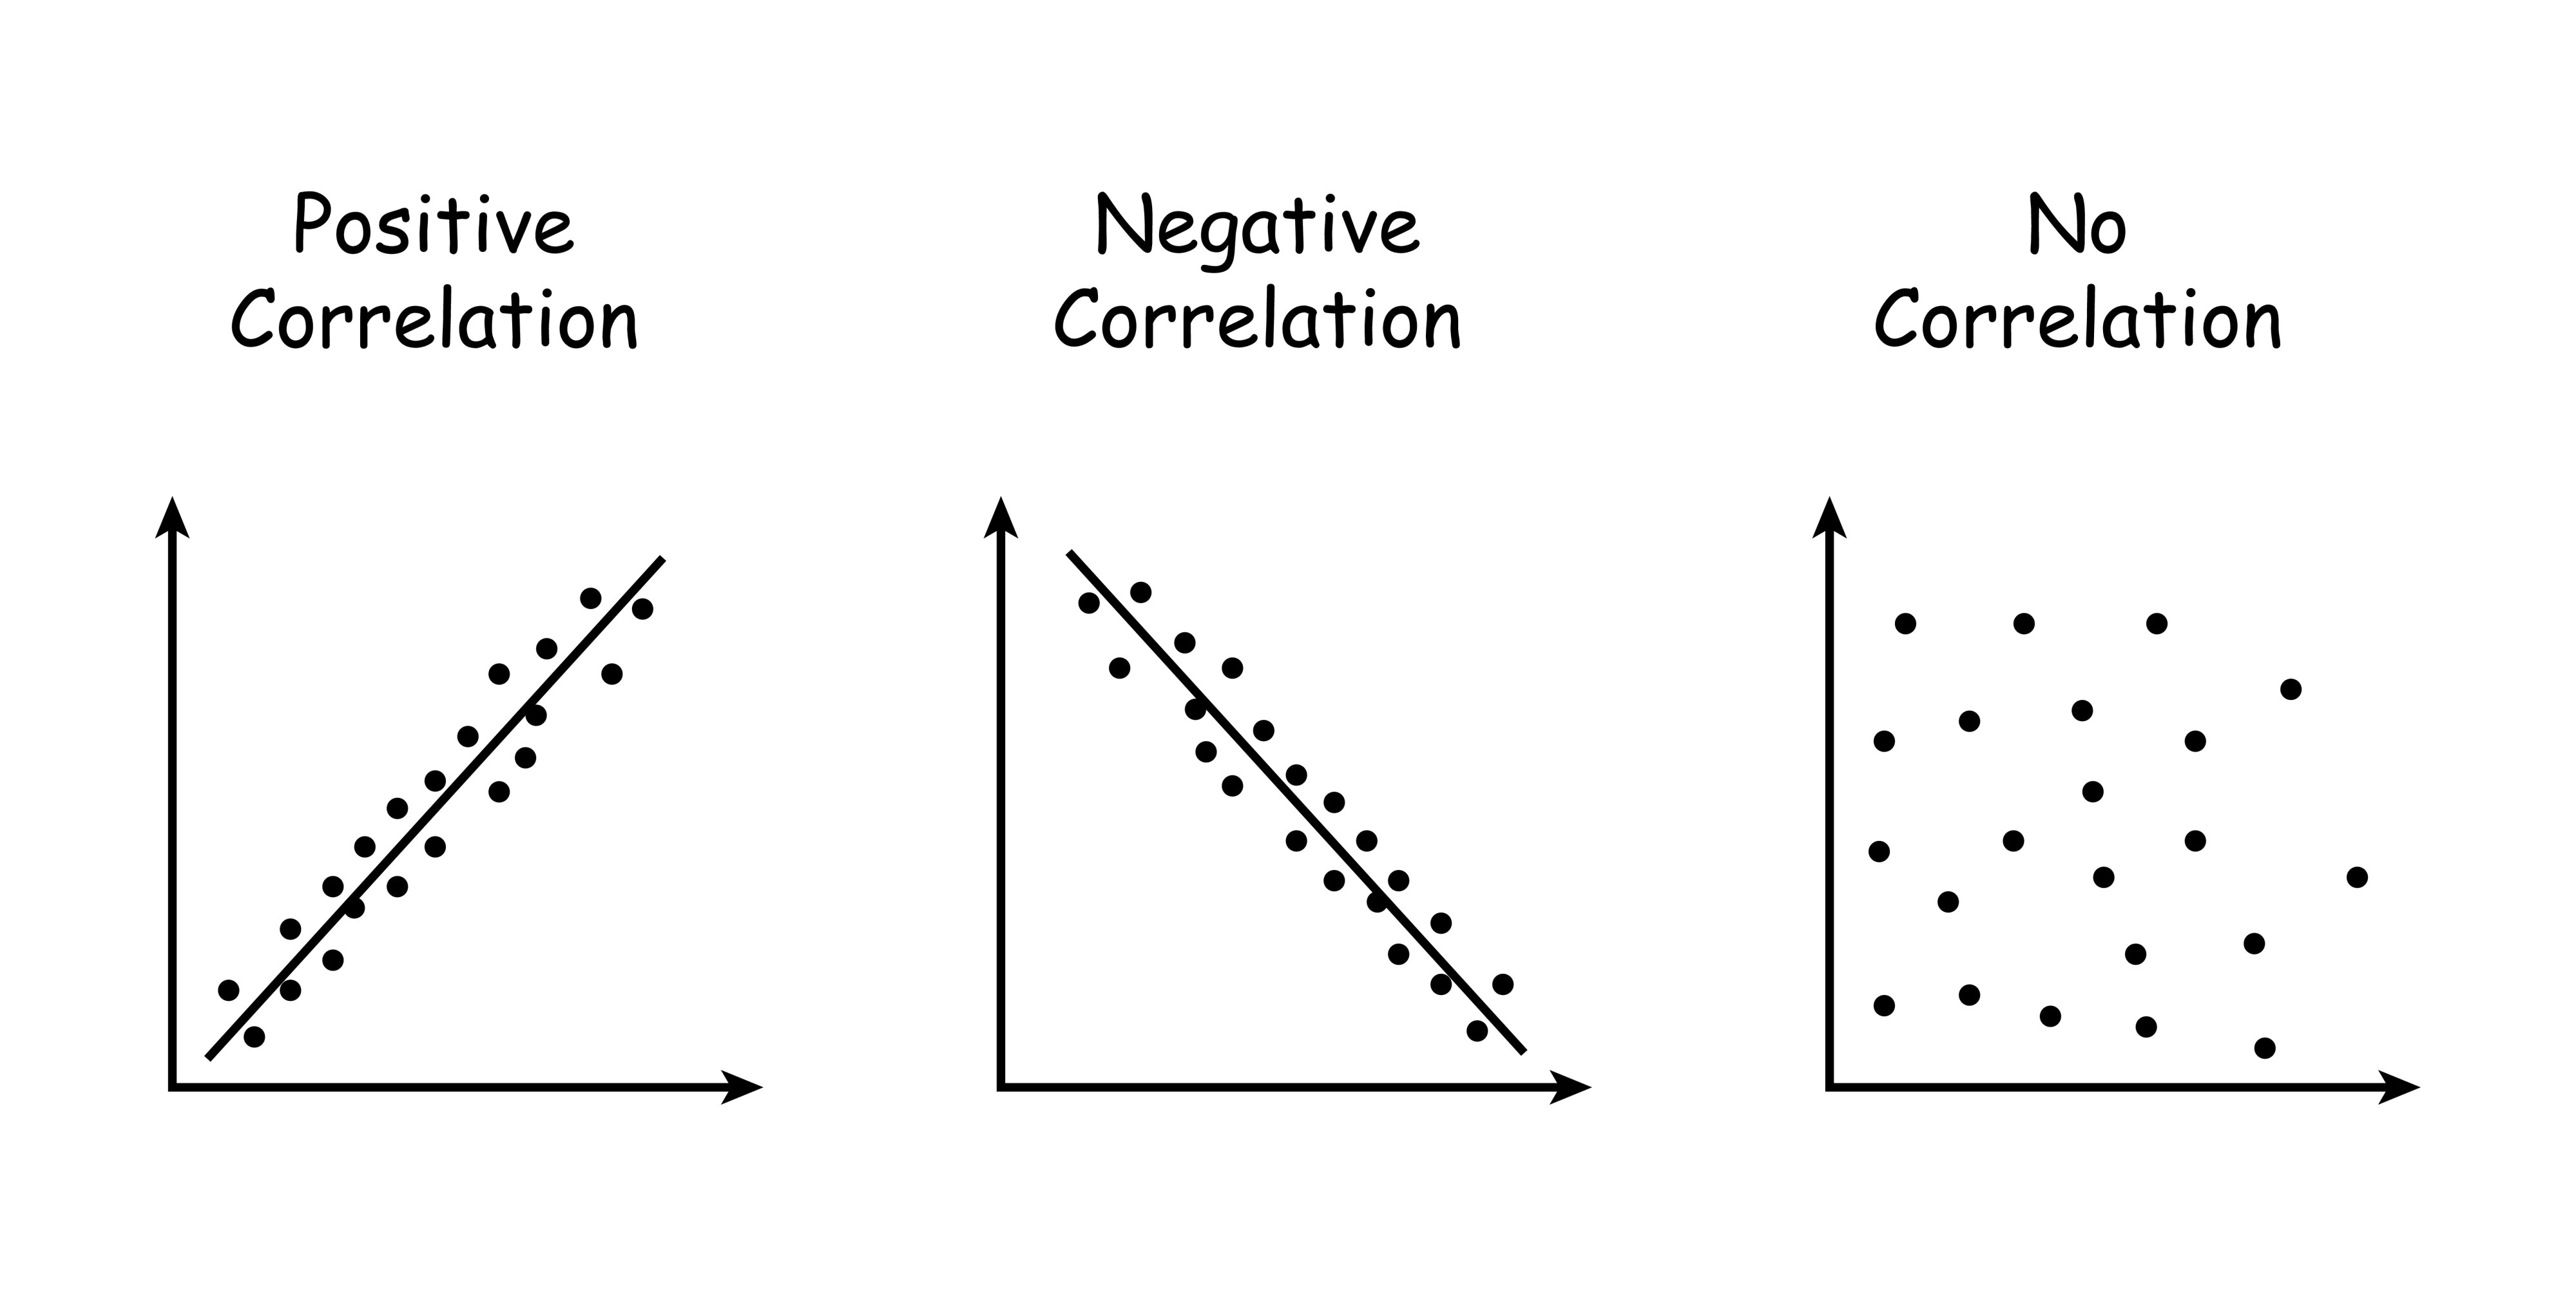

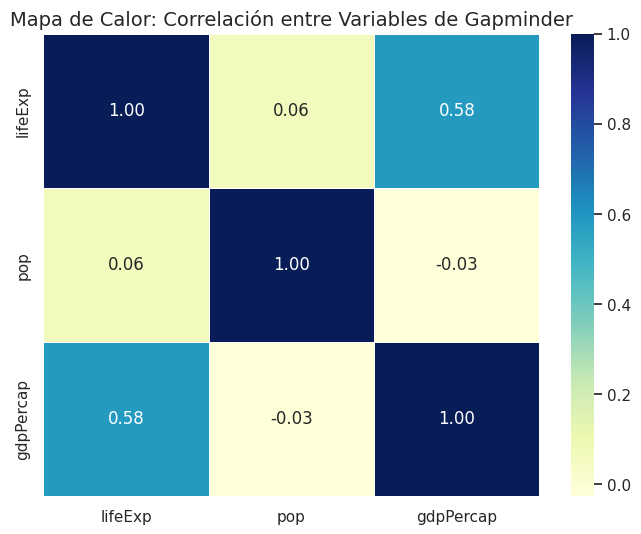

In [14]:
plt.figure(figsize=(8, 6))

# Creamos el mapa de calor
# annot=True pone los números dentro de los cuadros
# cmap="YlGnBu" define los colores (Amarillo-Verde-Azul)
sns.heatmap(matriz_correlacion, annot=True, cmap="YlGnBu", fmt=".2f", linewidths=0.5)

# Títulos
plt.title("Mapa de Calor: Correlación entre Variables de Gapminder", fontsize=14)

plt.show()

### VIOLIN PLOT

- Un Boxplot en el centro (la línea blanca y la caja negra).
- Un KDE (Densidad) a los lados: Muestra la distribución. Si el violín es "panzón", hay mucha densidad ahí.

"El Boxplot nos decía dónde estaba el centro, pero el Violin Plot nos muestra además 'el cuerpo' de los datos. ¿Dónde se ensancha el violín? Ahí es donde están la mayoría de los países. Si el violín es muy delgado en una zona, significa que casi no hay países con esa esperanza de vida."

In [15]:
data_2007 = df[df['year'] == 2007]

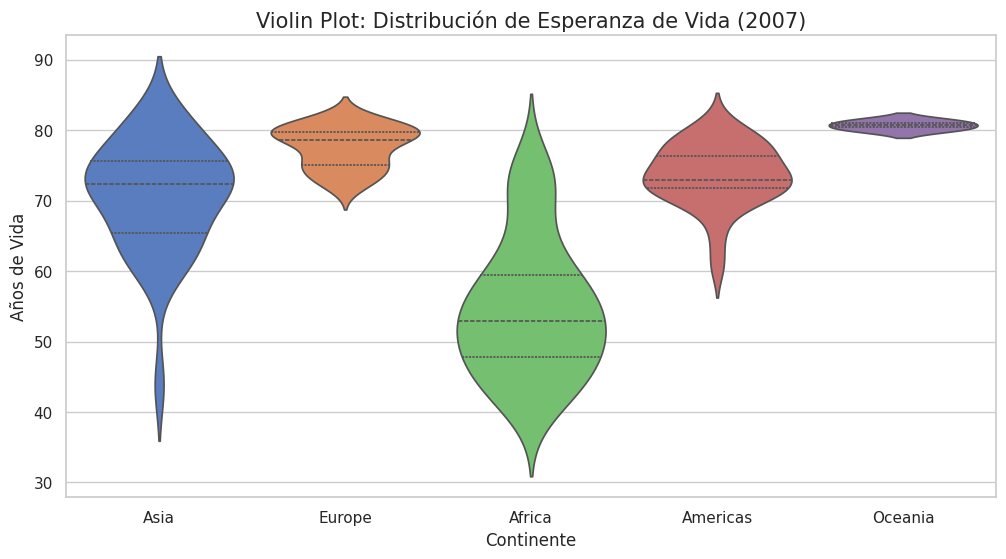

In [16]:
plt.figure(figsize=(12, 6))

# Creamos el violinplot
# inner="quartile" dibuja las líneas de los percentiles dentro del violín
sns.violinplot(data=data_2007, x="continent", y="lifeExp", palette="muted", inner="quartile", hue="continent", legend=False)

# Títulos
plt.title("Violin Plot: Distribución de Esperanza de Vida (2007)", fontsize=15)
plt.xlabel("Continente")
plt.ylabel("Años de Vida")

plt.show()

- La Anchura: "Si el violín de Europa es muy ancho arriba (en los 80 años), significa que casi todos sus países están amontonados en esa edad".
- La Longitud: "Si el violín es muy largo (como el de África), significa que hay países con realidades muy distintas: unos viven poco y otros viven mucho más".
- La Simetría: El violín es simétrico para que sea más fácil de ver, pero ambos lados representan la misma información de frecuencia.

### SWARMPLOT

A diferencia de un gráfico de dispersión normal, el Swarm Plot separa los puntos para que no se encimen, permitiéndonos ver exactamente cuántos países hay en cada nivel de salud o riqueza.

"En el año 2007, ¿cómo se ven los países de cada continente si los ponemos como puntos en una gráfica? ¿Ves grupos de países que están 'atrapados' en niveles bajos de vida, o están todos dispersos? Vamos a ver el enjambre de naciones."

In [17]:
data_2007 = df[df['year'] == 2007]

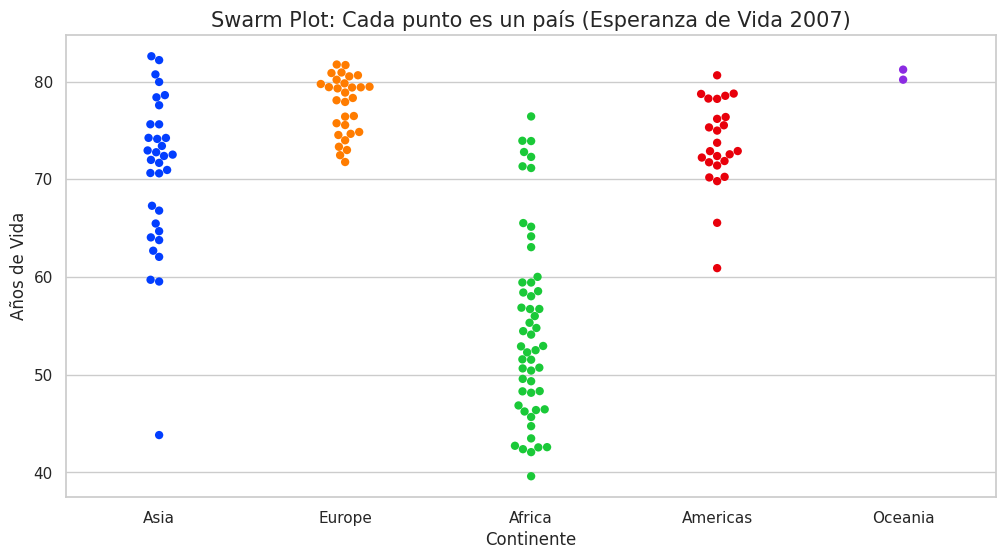

In [18]:
plt.figure(figsize=(12, 6))

# Creamos el swarmplot
# size=5 ajusta el tamaño de los puntos (países)
sns.swarmplot(data=data_2007, x="continent", y="lifeExp", palette="bright", size=6, hue="continent", legend=False)

# Títulos
plt.title("Swarm Plot: Cada punto es un país (Esperanza de Vida 2007)", fontsize=15)
plt.xlabel("Continente")
plt.ylabel("Años de Vida")

plt.show()

- Datos Individuales: A diferencia del promedio, aquí el alumno puede "contar" los países. Puede ver, por ejemplo, que en Oceanía solo hay dos puntos, mientras que en África hay una nube densa.
- Densidad Visual: Es muy fácil ver dónde está la "multitud". Si hay una zona muy ancha en el enjambre, es que muchos países comparten esa misma realidad.
- Detección de Brechas: Notarás que en algunos continentes hay un grupo de puntos arriba y otros muy abajo, con un vacío en medio. Eso muestra una división social o económica geográfica.

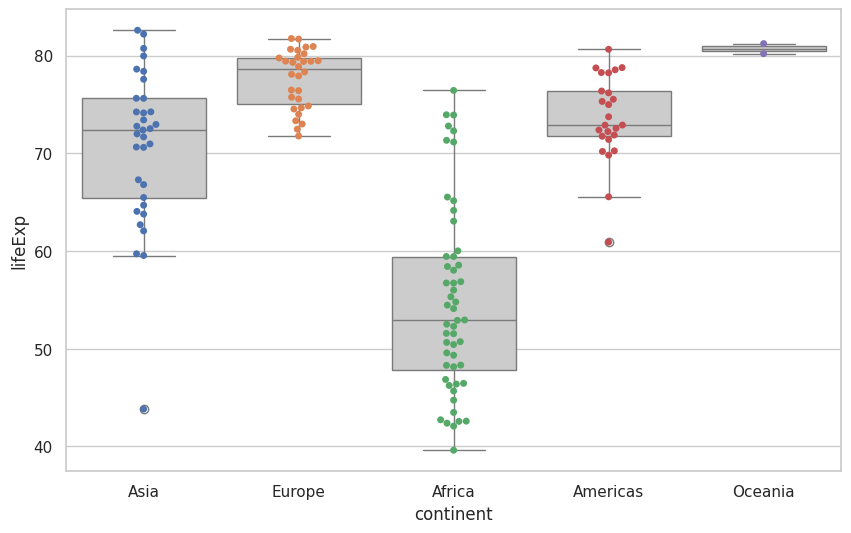

In [19]:
plt.figure(figsize=(10,6))
# Dibujamos el boxplot de fondo (color gris claro)
sns.boxplot(data=data_2007, x="continent", y="lifeExp", color=".8")
# Encimamos el swarmplot
sns.swarmplot(data=data_2007, x="continent", y="lifeExp", hue="continent")
plt.show()

### Plots de Matrices

In [20]:
# Esto filtrará automáticamente solo las columnas con números (año, población, PIB, etc.)
mat = df.corr(numeric_only=True)
mat

,year,pop,lifeExp,gdpPercap
year,1.000000,0.082308,0.435611,0.227318
pop,0.082308,1.000000,0.064955,-0.025600
lifeExp,0.435611,0.064955,1.000000,0.583706
gdpPercap,0.227318,-0.025600,0.583706,1.000000


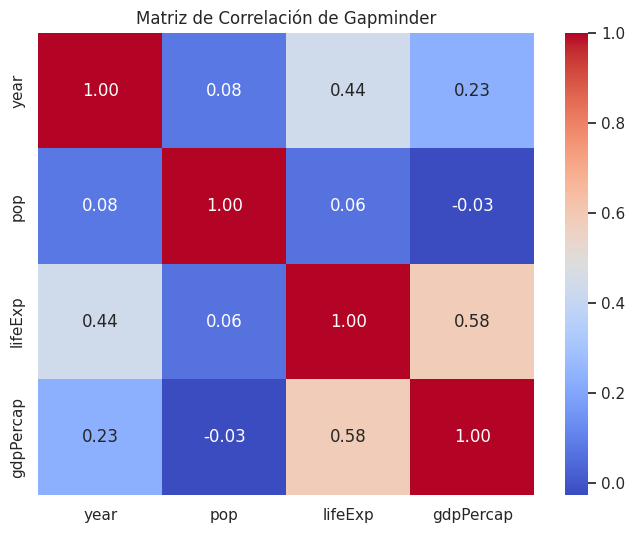

In [21]:
# 2. La graficamos
plt.figure(figsize=(8, 6))
sns.heatmap(mat, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Matriz de Correlación de Gapminder")
plt.show()

### Regresión

La regresión aquí cumple dos funciones principales:

- Describir la relación: Al ver la inclinación de la línea, confirmas visualmente que a mayor PIB, mayor esperanza de vida (una correlación positiva).
- Predicción: Si tuvieras un país con un PIB que no está en tu lista, podrías mirar la línea roja para "predecir" qué esperanza de vida le correspondería según la tendencia global de 2007.

"Si sabemos que a mayor PIB, mayor es la esperanza de vida, ¿podríamos predecir cuántos años viviría la gente en un país que tiene un PIB de 20,000 dólares? La línea de regresión nos da la 'pista' de hacia dónde van los datos."

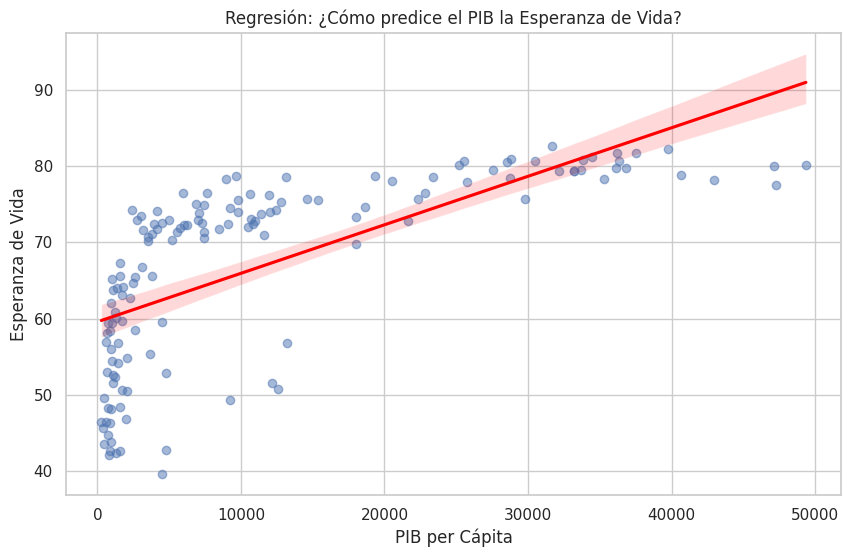

In [25]:
data_2007 = df[df['year'] == 2007]

plt.figure(figsize=(10, 6))

# regplot dibuja los puntos Y la línea de tendencia automática
sns.regplot(data=data_2007, x="gdpPercap", y="lifeExp", 
            scatter_kws={'alpha':0.5}, # Puntos un poco transparentes
            line_kws={'color':'red'})   # Línea de regresión en rojo

plt.title("Regresión: ¿Cómo predice el PIB la Esperanza de Vida?")
plt.xlabel("PIB per Cápita")
plt.ylabel("Esperanza de Vida")

plt.show()

En este gráfico específico (PIB vs Esperanza de Vida), la relación suele ser curva (logarítmica) más que una línea recta perfecta. Si notas que los puntos se curvan mucho y la línea roja "falla" en los extremos, podrías probar aplicar un logaritmo al eje X.

### El lmplot

El lmplot es el hermano mayor del regplot. Mientras que regplot solo dibuja una línea para un grupo de datos, el lmplot (Linear Model Plot) nos permite comparar varias regresiones al mismo tiempo usando colores.

Es perfecto para ver si la relación dinero-salud funciona igual en todos los continentes.

"¿La riqueza ayuda igual a todos los continentes? Vamos a comparar las líneas de tendencia de América y Europa. Si una línea es más empinada que la otra, significa que en ese continente el dinero 'compra' años de vida más rápido. ¿Quién tiene la pendiente más alta?"

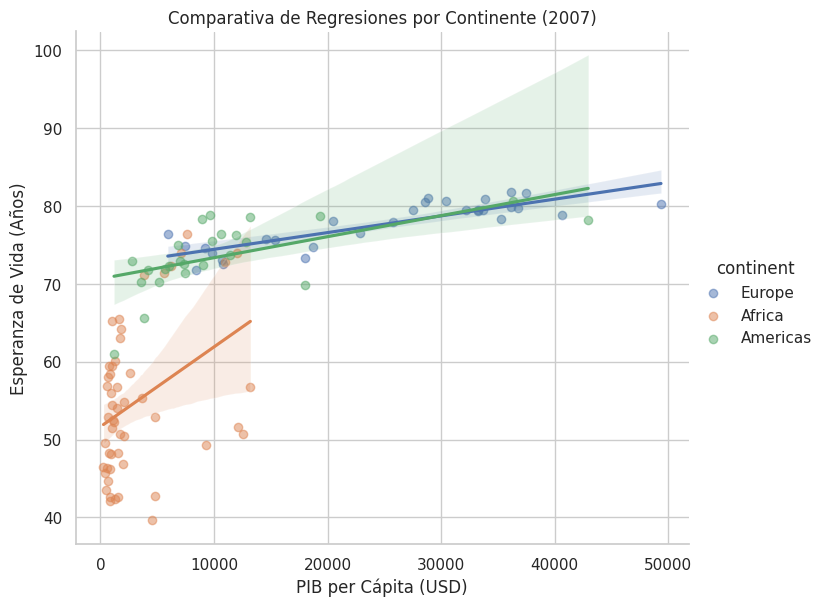

In [26]:
# Filtramos para no saturar el gráfico, comparemos tres continentes
filt_cont = df[df['continent'].isin(['Americas', 'Europe', 'Africa']) & (df['year'] == 2007)]

# Creamos el lmplot
# hue="continent" crea una línea de diferente color para cada uno
sns.set_theme(style="whitegrid")
g = sns.lmplot(data=filt_cont, x="gdpPercap", y="lifeExp", hue="continent", 
               height=6, aspect=1.2, scatter_kws={'alpha':0.5})

# Personalización
plt.title("Comparativa de Regresiones por Continente (2007)")
g.set_axis_labels("PIB per Cápita (USD)", "Esperanza de Vida (Años)")

plt.show()